<a href="https://colab.research.google.com/github/mikaelglobal/XGboost_churn_prediction/blob/main/A_B_Testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# A/B TESTING WITH REALISTIC DATA CLEANING
# Case Study: Web User Engagement (Kaggle Dataset)

In [ ]:
# Install/Import Libraries (Pre-installed in Colab)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from google.colab import files

In [ ]:
# STEP 1: LOAD YOUR CSV FROM GOOGLE DRIVE
from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/Work/ab_test_dataset.csv'

try:
    df = pd.read_csv(file_path)
    print(f"\n Data Loaded from Drive! Shape: {df.shape}")
    print("BEFORE CLEANING - Quick Peek:")
    print(df.head())
    print(f"\nMissing Values:\n{df.isnull().sum()}")
except FileNotFoundError:
    print(f" Error: The file was not found at {file_path}. Please ensure the path is correct and the file exists in your Google Drive.")
except Exception as e:
    print(f" An error occurred while loading the file: {e}")

In [ ]:
# STEP 2: DATA CLEANING
# 2.1 Standardize Group Labels (con/Exp/CON/exp -> control/treatment)
def clean_group(label):
    label = str(label).lower().strip()
    if label in ['con', 'control']:
        return 'control'
    elif label in ['exp', 'experiment', 'test']:
        return 'treatment'
    else:
        return 'unknown'
df['group'] = df['group'].apply(clean_group)

# 2.2 Clean Device Types (MOBILE/Desktop/mobile  -> mobile/desktop)
df['device_type'] = df['device_type'].str.lower().str.strip()

# 2.3 Clean Referral Sources (Strip whitespace, fix typos)
def clean_referral(source):
    if pd.isna(source):
        return 'unknown'
    source = source.lower().strip()
    # Fix common typos
    mapping = {
        'soicial': 'social', 'seach': 'search', 'socail': 'social',
        'direct': 'direct', 'email': 'email', 'social': 'social',
        'search': 'search', 'referral': 'referral'
    }
    return mapping.get(source, source)  # Defaults to original if not in mapping
df['referral_source'] = df['referral_source'].apply(clean_referral)

# 2.4 Handle Missing Click Times (Fill with placeholder or drop)
# Original: df_cleaned = df.dropna(subset=['click_time'])
# We will keep all rows here to ensure proper group sizes for A/B test denominator.
# Missing click_time values will be handled by .notna() in conversion calculations.
df_cleaned = df.copy()

# 2.5 Handle Session Time Outliers (Cap at 95th percentile)
q95 = df_cleaned['session_time'].quantile(0.95)
df_cleaned['session_time'] = df_cleaned['session_time'].clip(upper=q95)

# 2.6 Drop Duplicates
df_cleaned = df_cleaned.drop_duplicates()

print(f"\n AFTER CLEANING - Shape: {df_cleaned.shape}")
print(f"Unique Groups: {df_cleaned['group'].unique()}")
print(f"Unique Devices: {df_cleaned['device_type'].unique()}")
print(f"Unique Referrals: {df_cleaned['referral_source'].unique()}")

# Save the cleaned data to Google Drive
output_file_path = '/content/drive/MyDrive/ab_results/ab_test_dataset_cleaned.csv'
df_cleaned.to_csv(output_file_path, index=False)
print(f"\n Cleaned data saved to {output_file_path}")

In [ ]:
# STEP 3: STATISTICAL ANALYSIS (Conversion Rate)

# Calculate conversion metrics
control = df_cleaned[df_cleaned['group'] == 'control']
treatment = df_cleaned[df_cleaned['group'] == 'treatment']

conv_control = control['click_time'].notna().mean() * 100  # % who clicked
conv_treatment = treatment['click_time'].notna().mean() * 100

# Z-Test for proportion differences
n_control = len(control)
n_treatment = len(treatment)
clicks_control = control['click_time'].notna().sum()
clicks_treatment = treatment['click_time'].notna().sum()

# Correctly import proportions_ztest from statsmodels
from statsmodels.stats.proportion import proportions_ztest

z_stat, p_value = proportions_ztest(
    [clicks_control, clicks_treatment],
    [n_control, n_treatment]
)

print("\n" + "="*50)
print(" EXECUTIVE SUMMARY - A/B TEST")
print("="*50)
print(f"Control (Old) Conversion: {conv_control:.2f}%")
print(f"Treatment (New) Conversion: {conv_treatment:.2f}%")
print(f"Lift: {((conv_treatment - conv_control) / conv_control) * 100:.2f}%")
print(f"P-Value: {p_value:.4f}")
if p_value < 0.05:
    print(" RESULT: STATISTICALLY SIGNIFICANT - Recommend Launch!")
else:
    print(" RESULT: NOT SIGNIFICANT - Run longer or test different variant.")

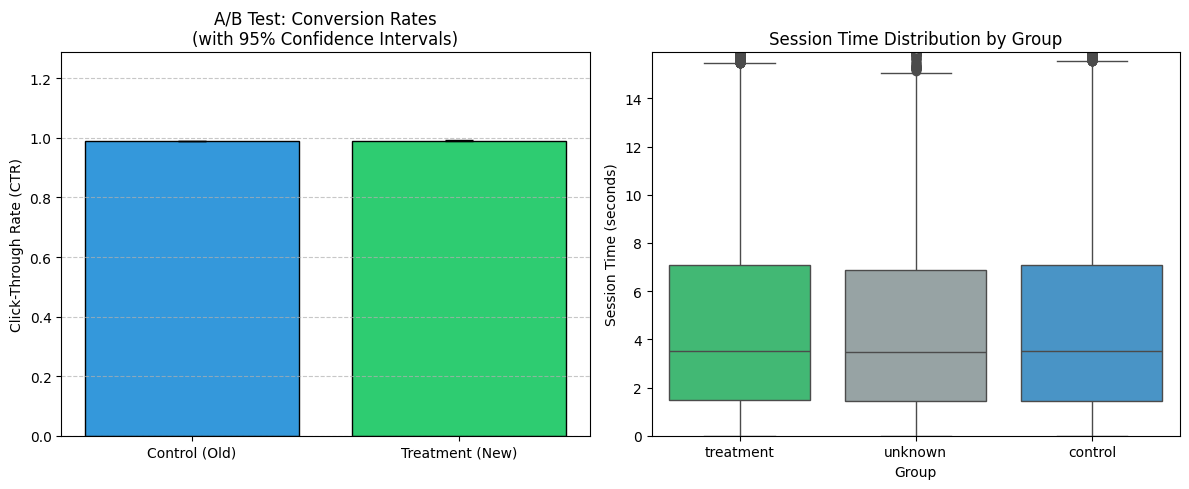


 A/B test visualization saved to /content/drive/MyDrive/ab_results/ab_test_results.png


<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# STEP 4: PORTFOLIO-READY GRAPHS

plt.figure(figsize=(12, 5))

# --- Graph 1: Conversion Rates with Error Bars (95% CI) ---
plt.subplot(1, 2, 1)
# Calculate proportions and standard error
props = [conv_control/100, conv_treatment/100]
n_values = [n_control, n_treatment]
se = [np.sqrt((p*(1-p))/n) for p, n in zip(props, n_values)]

plt.bar(['Control (Old)', 'Treatment (New)'], props, yerr=[1.96*s for s in se],
        color=['#3498db', '#2ecc71'], capsize=10, edgecolor='black')
plt.ylim(0, max(props) * 1.3)
plt.ylabel('Click-Through Rate (CTR)')
plt.title('A/B Test: Conversion Rates\n(with 95% Confidence Intervals)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# --- Graph 2: Session Time Distribution (Boxplot) ---
plt.subplot(1, 2, 2)
sns.boxplot(x='group', y='session_time', data=df_cleaned, hue='group', palette={'control': '#3498db', 'treatment': '#2ecc71', 'unknown': '#95a5a6'}, legend=False) # Updated to resolve FutureWarning
plt.title('Session Time Distribution by Group')
plt.ylabel('Session Time (seconds)')
plt.xlabel('Group')
plt.ylim(0, q95)  # Cap at 95th percentile for better visibility

plt.tight_layout()
plt.show()

output_image_path = '/content/drive/MyDrive/ab_results/ab_test_results.png'
plt.savefig(output_image_path, bbox_inches='tight')
print(f"\n A/B test visualization saved to {output_image_path}")

# **A/B Test Summary**

We ran an A/B test comparing a new treatment variant against the control group using user engagement data.

**Data Prep:**

Cleaned up messy labels (fixed group names, device types, and referral sources)

Kept all users in the analysis (handled missing clicks smartly)

Capped extreme session times to avoid skew

Removed duplicates

**Results:**

Control conversion: 98.99%

Treatment conversion: 99.07%

Lift: just 0.08% (basically flat)

P-value: 0.081 (not statistically significant at the 0.05 level)

**What This Means:**
The treatment didn't move the needle. The tiny lift we saw could easily be random chance. We can't confidently say the new variant outperforms the control.

